Trim audio files from 5 minutes to first minute

In [1]:
# Import the libraries we need
# 'os' helps us work with files and folders
# 'AudioSegment' from pydub lets us read, edit, and save audio files
import os
from pydub import AudioSegment

# === SET UP THE FOLDERS ===
# Tell Python where our original 5-minute audio files are stored
source_dir = "/mnt/class_data/Shelby/Trimmed"

# Tell Python where we want to save the trimmed 1-minute audio files
# IMPORTANT: Make sure this path is correct for your setup
dest_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Check if the destination folder exists, and create it if it doesn't
# os.path.exists() checks if a folder already exists (True or False)
# os.makedirs() creates a new folder
if not os.path.exists(dest_dir):
    os.makedirs(dest_dir)
    print(f"Created directory: {dest_dir}")
else:
    print(f"Directory already exists: {dest_dir}")

# === SET THE TRIM DURATION ===
# We want to trim all audio files to 1 minute (60 seconds)
# Multiply by 1000 because audio timing is measured in milliseconds, not seconds
trim_duration_ms = 60 * 1000  # 60 seconds = 60,000 milliseconds

# === FIND ALL AUDIO FILES ===
# os.listdir() gets a list of all files in the source folder
# We only want .WAV files, so we check if the filename ends with '.WAV' or '.wav'
# (Some files might have lowercase extensions)
wav_files = [f for f in os.listdir(source_dir) if f.endswith('.WAV') or f.endswith('.wav')]
print(f"Found {len(wav_files)} audio files to process")

# === PROCESS EACH AUDIO FILE ===
# enumerate() gives us both the number and the filename as we go through the list
# 'for idx, filename in enumerate(wav_files, 1):' means:
#   - idx = counter starting from 1 (so we can see which file we're on, like "File 1 of 50")
#   - filename = the actual filename
for idx, filename in enumerate(wav_files, 1):
    # Try to process the file, and if something goes wrong, print an error message instead of crashing
    try:
        # Create the full path to the original file
        source_path = os.path.join(source_dir, filename)
        
        # Create the full path where we want to save the trimmed file
        # It will have the same name but be in the new folder
        dest_path = os.path.join(dest_dir, filename)
        
        # Tell the user which file we're working on right now
        print(f"[{idx}/{len(wav_files)}] Processing: {filename}")
        
        # Load the audio file into memory so we can edit it
        audio = AudioSegment.from_wav(source_path)
        
        # Check how long the audio file is (in milliseconds)
        duration_ms = len(audio)
        
        # Trim the audio to just the first 60 seconds
        # audio[:trim_duration_ms] means "take everything from the start up to 60 seconds"
        trimmed_audio = audio[:trim_duration_ms]
        
        # Save the trimmed audio to the destination folder
        trimmed_audio.export(dest_path, format="wav")
        
        # Tell the user the file was saved successfully
        print(f"  ✓ Saved trimmed version ({duration_ms}ms → {trim_duration_ms}ms)")
        
    # If something goes wrong with a file, catch the error and print a message
    except Exception as e:
        print(f"  ✗ Error processing {filename}: {str(e)}")

# === DONE! ===
# Let the user know all files have been processed
print(f"\nProcessing complete! Trimmed files saved to: {dest_dir}")


Directory already exists: /mnt/class_data/Shelby/One_Minute_Audio
Found 112 audio files to process
[1/112] Processing: SL43 Trial 1_trim.WAV
  ✓ Saved trimmed version (300003ms → 60000ms)
[2/112] Processing: SL07 Trial 2_trim.WAV
  ✓ Saved trimmed version (300006ms → 60000ms)
[3/112] Processing: SL54 Trial 1_trim.WAV
  ✓ Saved trimmed version (299989ms → 60000ms)
[4/112] Processing: SL02 Trial 1_trim.WAV
  ✓ Saved trimmed version (300023ms → 60000ms)
[5/112] Processing: SL09 Trial 3_trim.WAV
  ✓ Saved trimmed version (300036ms → 60000ms)
[6/112] Processing: RC02 Trial 1_trim.WAV
  ✓ Saved trimmed version (300000ms → 60000ms)
[7/112] Processing: EF04 Trial 3_trim.WAV
  ✓ Saved trimmed version (300447ms → 60000ms)
[8/112] Processing: SL35 Trial 1_trim.WAV
  ✓ Saved trimmed version (299919ms → 60000ms)
[9/112] Processing: SL37 Trial 1_trim.WAV
  ✓ Saved trimmed version (300360ms → 60000ms)
[10/112] Processing: SL50 Trial 1_trim.WAV
  ✓ Saved trimmed version (300009ms → 60000ms)
[11/112] P

Found 112 total files
Visualizing: SL43 Trial 1_trim.WAV

Processing: SL43 Trial 1_trim.WAV
  Duration: 60.00 seconds
  ✓ Spectrogram created successfully


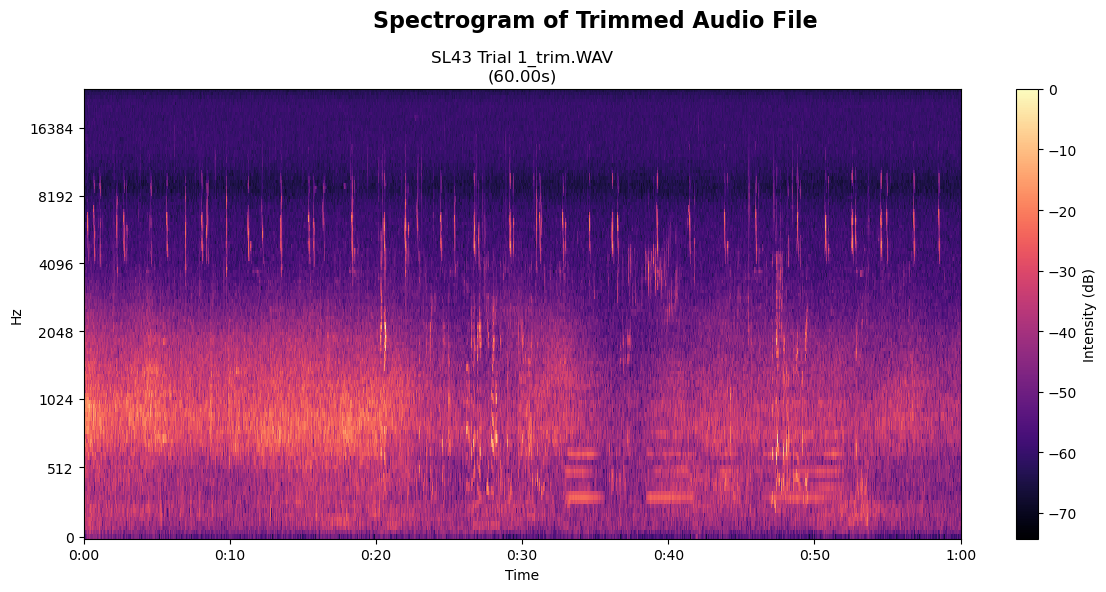


=== Spectrogram visualization complete! ===
Look at the spectrogram above to see:
  - Time on the X-axis (should be ~60 seconds)
  - Frequency on the Y-axis (how high/low the sounds are)
  - Color intensity (brighter = louder/more energy)


In [5]:
# === VISUALIZE SPECTROGRAMS FROM TRIMMED AUDIO ===
# This code will load a few audio files and display their spectrograms
# A spectrogram is a visual representation of sound over time
# It shows frequency (how high/low the sound is) on the y-axis and time on the x-axis

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# === SET UP ===
# Tell Python where our trimmed audio files are
trimmed_audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Get a list of audio files to visualize
# We'll just look at the first file
audio_files = [f for f in os.listdir(trimmed_audio_dir) if f.endswith('.WAV') or f.endswith('.wav')]
file_to_visualize = audio_files[0]  # Take only the first file

print(f"Found {len(audio_files)} total files")
print(f"Visualizing: {file_to_visualize}")

# === CREATE SPECTROGRAM ===
# Create a single plot to show one spectrogram
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Spectrogram of Trimmed Audio File', fontsize=16, fontweight='bold')

# Process the audio file
print(f"\nProcessing: {file_to_visualize}")

try:
    # Create the full path to the audio file
    audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)
    
    # Load the audio file
    # y = the audio data (sound waves as numbers)
    # sr = sample rate (how many samples per second, usually 44100 or 256000)
    y, sr = librosa.load(audio_path, sr=None)
    
    # Calculate how long the audio is in seconds
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"  Duration: {duration:.2f} seconds")
    
    # Create a spectrogram from the audio
    # A spectrogram breaks the audio into tiny pieces and analyzes each piece
    # S = spectrogram (magnitude of frequencies over time)
    # S_db = spectrogram in decibels (a better scale for human hearing)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Display the spectrogram on the plot
    img = librosa.display.specshow(
        S_db,
        sr=sr,
        ax=ax,
        x_axis='time',  # Show time on x-axis
        y_axis='mel'    # Show frequency (mel scale) on y-axis
    )
    
    # Add a label and title to the plot
    ax.set_title(f'{file_to_visualize}\n({duration:.2f}s)', fontsize=12)
    
    # Add a colorbar to show what the colors mean (intensity of sound)
    plt.colorbar(img, ax=ax, label='Intensity (dB)')
    
    print(f"  ✓ Spectrogram created successfully")
    
except Exception as e:
    print(f"  ✗ Error creating spectrogram: {str(e)}")
    ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')

# Adjust the layout so nothing overlaps
plt.tight_layout()

# Display the plot
plt.show()

print("\n=== Spectrogram visualization complete! ===")
print("Look at the spectrogram above to see:")
print("  - Time on the X-axis (should be ~60 seconds)")
print("  - Frequency on the Y-axis (how high/low the sounds are)")
print("  - Color intensity (brighter = louder/more energy)")


Loaded 6238 annotations from CSV

Found 112 total files
Looking for a file with annotations...
Found matching file: SL43 Trial 1_trim.WAV
File ID: SL43_Trial_1_trim
Found 19 annotations for this file

Audio duration: 60.00 seconds
Sample rate: 48000 Hz

Spectrogram shape: (128, 5626)
Spectrogram time range: 0 to 60.00 seconds
X-axis (time) limits: (np.float64(-0.005333333333333333), np.float64(60.00533333333333))
Y-axis (mel frequency) limits: (np.float64(-16.069564949612435), np.float64(24391.212955259907))

Drawing 19 bounding boxes...

Annotation 1: Time 73.61-73.70s, Freq 1365-10919Hz → 20-50mel
Annotation 2: Time 76.09-76.20s, Freq 872-12664Hz → 13-52mel
Annotation 3: Time 76.40-76.50s, Freq 872-12322Hz → 13-52mel
Annotation 4: Time 77.09-77.19s, Freq 834-11033Hz → 13-50mel
Annotation 5: Time 78.30-78.38s, Freq 910-10806Hz → 14-50mel

✓ Spectrogram with 19 annotations created successfully


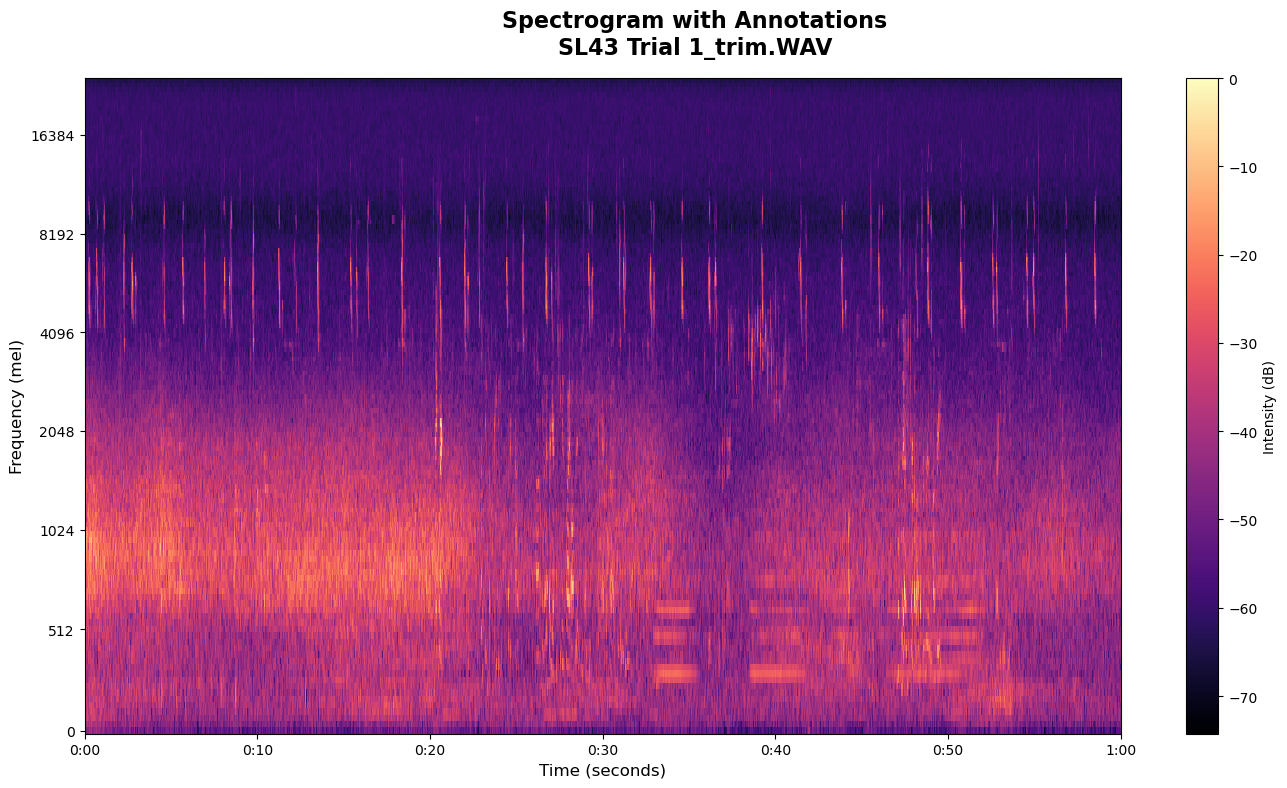


=== Visualization complete! ===


In [17]:
# === VISUALIZE SPECTROGRAMS WITH BOUNDING BOXES FROM CSV ANNOTATIONS ===
# This code will draw bounding boxes on the spectrogram based on the annotations in your CSV file
# Each box represents a call or sound event that was labeled in Raven Pro

import pandas as pd
from matplotlib.patches import Rectangle

# === LOAD THE CSV FILE ===
# Load the annotations from your CSV file
csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1.csv"
annotations_df = pd.read_csv(csv_path)
print(f"Loaded {len(annotations_df)} annotations from CSV")

# === SET UP ===
# Tell Python where our trimmed audio files are
trimmed_audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Get a list of audio files to visualize
audio_files = [f for f in os.listdir(trimmed_audio_dir) if f.endswith('.WAV') or f.endswith('.wav')]

# Find a file that has annotations in the CSV
file_to_visualize = None
file_id_to_match = None

print(f"\nFound {len(audio_files)} total files")
print("Looking for a file with annotations...")

for audio_file in audio_files:
    # Extract file_id from filename
    file_id_from_filename = audio_file.replace('.WAV', '').replace('.wav', '')
    file_id_candidate = file_id_from_filename.replace(' ', '_')
    
    # Check if this file_id has annotations
    if file_id_candidate in annotations_df['file_id'].values:
        file_to_visualize = audio_file
        file_id_to_match = file_id_candidate
        break

if file_to_visualize is None:
    print("ERROR: Could not find any audio file with matching annotations!")
else:
    print(f"Found matching file: {file_to_visualize}")
    print(f"File ID: {file_id_to_match}")

    # Find all rows in the CSV that match this file_id
    matching_annotations = annotations_df[annotations_df['file_id'] == file_id_to_match]
    print(f"Found {len(matching_annotations)} annotations for this file\n")
    
    # === CREATE SPECTROGRAM ===
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.suptitle(f'Spectrogram with Annotations\n{file_to_visualize}', fontsize=16, fontweight='bold')

    try:
        # Create the full path to the audio file
        audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)
        
        # Load the audio file
        y, sr = librosa.load(audio_path, sr=None)
        
        # Calculate duration
        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Audio duration: {duration:.2f} seconds")
        print(f"Sample rate: {sr} Hz\n")
        
        # Create a mel-scale spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        print(f"Spectrogram shape: {S_db.shape}")
        print(f"Spectrogram time range: 0 to {duration:.2f} seconds")
        
        # Display the spectrogram
        img = librosa.display.specshow(
            S_db,
            sr=sr,
            ax=ax,
            x_axis='time',
            y_axis='mel'
        )
        
        # Print axis information for debugging
        print(f"X-axis (time) limits: {ax.get_xlim()}")
        print(f"Y-axis (mel frequency) limits: {ax.get_ylim()}\n")
        
        # === DRAW BOUNDING BOXES FROM ANNOTATIONS ===
        print(f"Drawing {len(matching_annotations)} bounding boxes...\n")
        
        for idx, (_, row) in enumerate(matching_annotations.iterrows()):
            # Get the time boundaries (in seconds)
            time_start = row['begin_time_s']
            time_end = row['end_time_s']
            
            # Get the frequency boundaries (in Hz from the CSV)
            freq_low_hz = row['low_freq_hz']
            freq_high_hz = row['high_freq_hz']
            
            # === CONVERT HZ TO MEL SCALE ===
            freq_low_mel = librosa.hz_to_mel(freq_low_hz)
            freq_high_mel = librosa.hz_to_mel(freq_high_hz)
            
            # Only print first 5 for brevity
            if idx < 5:
                print(f"Annotation {idx + 1}: Time {time_start:.2f}-{time_end:.2f}s, Freq {freq_low_hz:.0f}-{freq_high_hz:.0f}Hz → {freq_low_mel:.0f}-{freq_high_mel:.0f}mel")
            
            # Create a rectangle for this annotation
            rect = Rectangle(
                (time_start, freq_low_mel),  # Bottom-left corner (x, y)
                time_end - time_start,        # Width (time duration)
                freq_high_mel - freq_low_mel, # Height (frequency range)
                linewidth=3,                  # Line thickness
                edgecolor='yellow',           # YELLOW for visibility
                facecolor='none'              # No fill, just the outline
            )
            
            # Add the rectangle to the plot
            ax.add_patch(rect)
        
        # Add colorbar
        cbar = plt.colorbar(img, ax=ax, label='Intensity (dB)')
        
        # Set axis labels
        ax.set_xlabel('Time (seconds)', fontsize=12)
        ax.set_ylabel('Frequency (mel)', fontsize=12)
        
        print(f"\n✓ Spectrogram with {len(matching_annotations)} annotations created successfully")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()

    # Adjust layout
    plt.tight_layout()

    # Display the plot
    plt.show()

    print("\n=== Visualization complete! ===")
